In [1]:
import os
import sys

src_dir = os.path.abspath(os.path.join(os.getcwd(), "../../..", "src"))
sys.path.append(src_dir)

from plot_scripts import setup_rc_params
# setup_rc_params()
from plot_scripts import plot_corner_3compare as plt_corner3
setup_rc_params(fontsize=14)
from plot_scripts_balldrop import plot_obs_model, plot_obs_modelPlusGP

# from plot_scripts_heavyion import plot_obs_model, plot_obs_modelPlusGP, plot_etabys

import numpy as np
from scipy.stats import beta
from scipy import optimize

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


## Some def

In [2]:
# Define function for general beta priors 
def log_prior_param(param, alpha_val, beta_val, param_min, param_max):
    """
    Log prior for parameter based on a Beta distribution.
    """
    scale = param_max - param_min  # Rescaling factor

    if param_min < param < param_max:
        # Rescale param to the range [param_min, param_max]
        param_rescaled = (param - param_min) / scale
        
        prior = beta.pdf(param_rescaled, alpha_val, beta_val) / scale
        return np.log(prior)
    else:
        return -np.inf

# ===========================================================================================

model_param_bounds = np.array([[ 0.0,   20.0 ],
                               [-2.0 ,  2.0  ]])

# Define a list of log_prior functions for model parameters
log_prior_theta = [
    lambda param, i=i: log_prior_param(
        param, alpha_val=1.01, beta_val=1.01,  # for flat priors
        param_min=model_param_bounds[i][0], param_max=model_param_bounds[i][1]
    )
    for i in range(len(model_param_bounds))
]
# ===========================================================================================


experimental_data = np.loadtxt('experimental_data.dat')
truth_data = np.loadtxt('truth.txt')

num_model_param = len(model_param_bounds)  # number of model parameters
colors = ['tab:red', 'tab:blue', 'tab:green']     # colors for predictions: red -> w/0 MD, blue -> w/ kernel 1, green -> w/ kernel 2


## Plot corner plots

In [3]:
delta = model_param_bounds[:, 1] - model_param_bounds[:, 0]
# Extend the bounds by 5% on each side
extended_bounds = np.column_stack((
    model_param_bounds[:, 0] - 0.05 * delta,
    model_param_bounds[:, 1] + 0.05 * delta
))
# ------------------------------------

true_param = [9.8, 0]
labels = [r'$g$', r'$v_0$']
legends = [r"$\mathrm{Without \ MD}$", r"$\mathrm{MD: Kernel\, I}$", r"$\mathrm{MD: Kernel\, II}$"]

# Add a legend on the diagonal
legend_lines = [
    Line2D([0], [0], color=colors[0], linewidth=2, label=legends[0]),
    Line2D([0], [0], color=colors[1], linewidth=2, label=legends[1]),
    Line2D([0], [0], color=colors[2], linewidth=2, label=legends[2])
]


/Users/jaiswal/miniconda3/envs/md/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


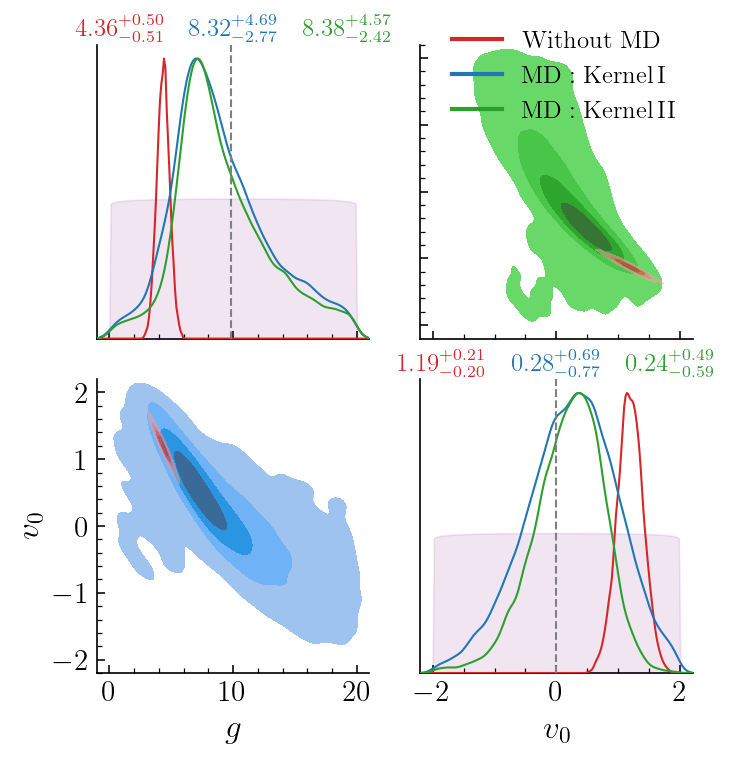

In [4]:
dir_path = "mcmc_data/height"

samples_wo_MD = np.load(f'{dir_path}/wo_MD/pocomc_chain_20000.npy')
samples_w_MD_kernel1 = np.load(f'{dir_path}/w_MD_kernel1/pocomc_chain_20000.npy')
samples_w_MD_kernel2 = np.load(f'{dir_path}/w_MD_kernel2/pocomc_chain_20000.npy')

samples1=samples_wo_MD[:,:num_model_param]
samples2= samples_w_MD_kernel1[:,:num_model_param]
samples3= samples_w_MD_kernel2[:,:num_model_param]

# ------------------------------------

g = plt_corner3(samples_1=samples1, samples_2=samples2, samples_3=samples3, 
                    color = colors, 
                    plot_labels=labels, 
                    param_ranges = extended_bounds,
                    truth = true_param,
                    priors = log_prior_theta)

gg = g.axes[0, 1]
gg.legend(
    handles=legend_lines,
    loc='upper right',
    bbox_to_anchor=(1.05, 1.15),
    bbox_transform=gg.transAxes,
    fontsize=12,
    frameon=False
)

# plt.tight_layout()
# g.savefig("corner_h.pdf", dpi=300, bbox_inches="tight")
plt.show()


/Users/jaiswal/miniconda3/envs/md/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


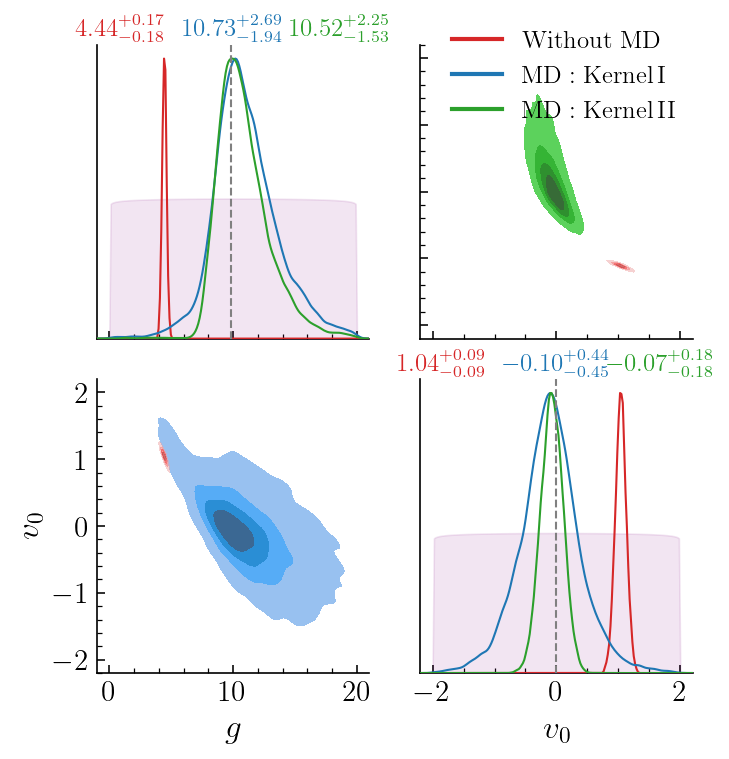

In [5]:
dir_path = "mcmc_data/height_vel"

samples_wo_MD = np.load(f'{dir_path}/wo_MD/pocomc_chain_20000.npy')
samples_w_MD_kernel1 = np.load(f'{dir_path}/w_MD_kernel1/pocomc_chain_20000.npy')
samples_w_MD_kernel2 = np.load(f'{dir_path}/w_MD_kernel2/pocomc_chain_20000.npy')

samples1=samples_wo_MD[:,:num_model_param]
samples2= samples_w_MD_kernel1[:,:num_model_param]
samples3= samples_w_MD_kernel2[:,:num_model_param]

# ------------------------------------

g = plt_corner3(samples_1=samples1, samples_2=samples2, samples_3=samples3, 
                    color = colors, 
                    plot_labels=labels, 
                    param_ranges = extended_bounds,
                    truth = true_param,
                    priors = log_prior_theta)

gg = g.axes[0, 1]
gg.legend(
    handles=legend_lines,
    loc='upper right',
    bbox_to_anchor=(1.05, 1.15),
    bbox_transform=gg.transAxes,
    fontsize=12,
    frameon=False
)

# plt.tight_layout()
# g.savefig("corner_h_v.pdf", dpi=300, bbox_inches="tight")
plt.show()


/Users/jaiswal/miniconda3/envs/md/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


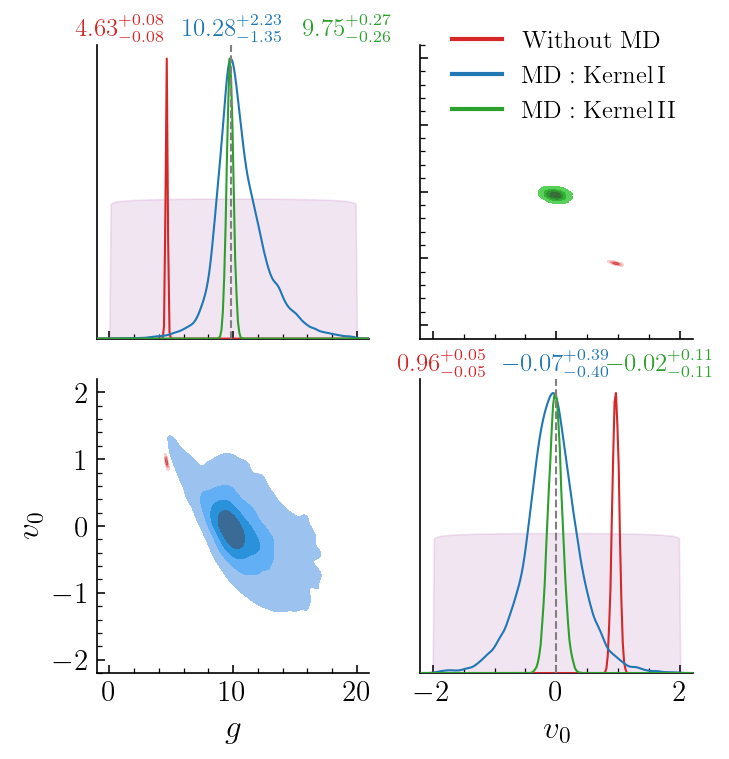

In [6]:
dir_path = "mcmc_data/height_vel_acc"

samples_wo_MD = np.load(f'{dir_path}/wo_MD/pocomc_chain_20000.npy')
samples_w_MD_kernel1 = np.load(f'{dir_path}/w_MD_kernel1/pocomc_chain_20000.npy')
samples_w_MD_kernel2 = np.load(f'{dir_path}/w_MD_kernel2/pocomc_chain_20000.npy')

samples1=samples_wo_MD[:,:num_model_param]
samples2= samples_w_MD_kernel1[:,:num_model_param]
samples3= samples_w_MD_kernel2[:,:num_model_param]

# ------------------------------------

g = plt_corner3(samples_1=samples1, samples_2=samples2, samples_3=samples3, 
                    color = colors, 
                    plot_labels=labels, 
                    param_ranges = extended_bounds,
                    truth = true_param,
                    priors = log_prior_theta)

gg = g.axes[0, 1]
gg.legend(
    handles=legend_lines,
    loc='upper right',
    bbox_to_anchor=(1.05, 1.15),
    bbox_transform=gg.transAxes,
    fontsize=12,
    frameon=False
)

# plt.tight_layout()
# g.savefig("corner_h_v_a.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Plot Model predictions

In [7]:
legends = ['Without MD: 95\% CI', 'MD: Kernel I: 95\% CI', 'MD: Kernel II: 95\% CI']

obs_labels = [
    r'Height ($m$)' , r'Velocity ($m/s$)', r'Acceleration ($m/s^2$)'
]

from plot_scripts_balldrop import plot_obs_model

/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2504.13144/ball-drop/plot_scripts_balldrop.py:100: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


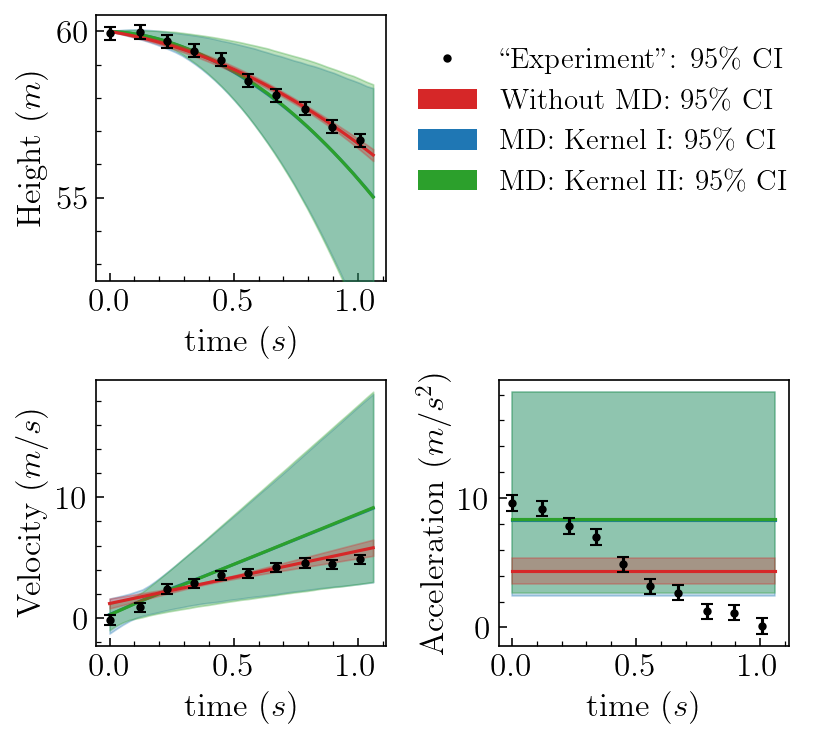

In [8]:
dir_path = "mcmc_data/height"

# load quantiles
num_samples = 20000
mod = 'model'
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_model(exp_data = experimental_data, truth = truth_data, 
               quantiles1 = quantiles_wo_MD, quantiles2 = quantiles_w_MD_kernel1, quantiles3 = quantiles_w_MD_kernel2, 
               true_param = true_param, colors = colors, obs_labels = obs_labels, legends = legends, fig_name=None)


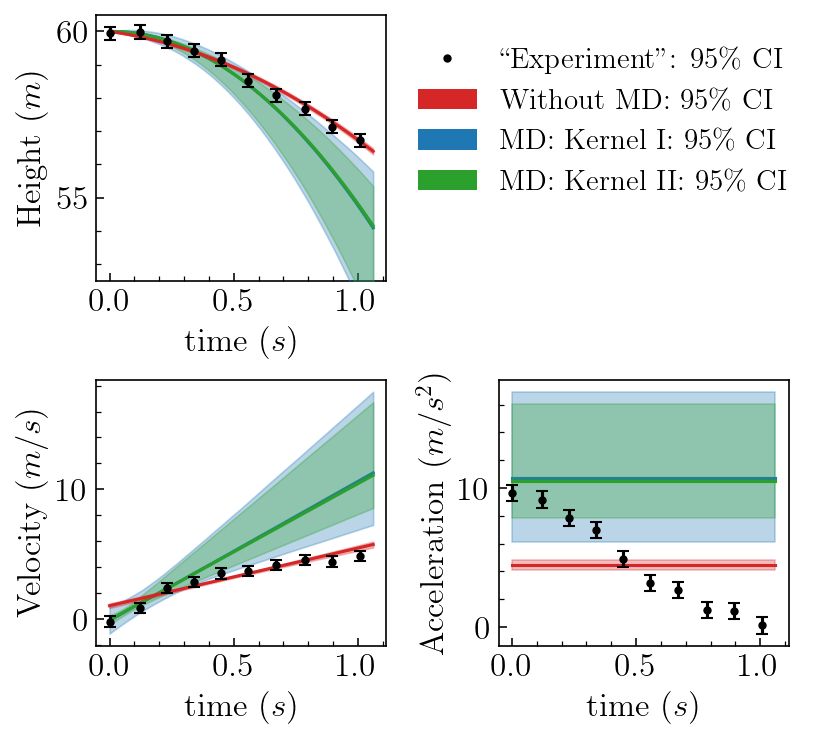

In [9]:
dir_path = "mcmc_data/height_vel"

# load quantiles
num_samples = 20000
mod = 'model'
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')



plot_obs_model(exp_data = experimental_data, truth = truth_data, 
               quantiles1 = quantiles_wo_MD, quantiles2 = quantiles_w_MD_kernel1, quantiles3 = quantiles_w_MD_kernel2, 
               true_param = true_param, colors = colors, obs_labels = obs_labels, legends = legends, fig_name=None)


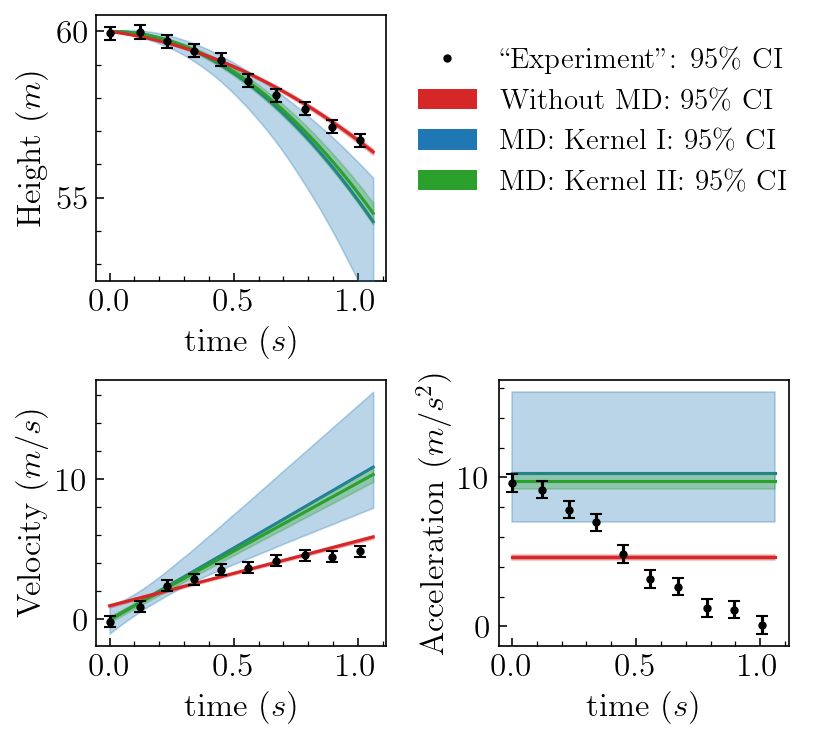

In [10]:
dir_path = "mcmc_data/height_vel_acc"

# load quantiles
num_samples = 20000
mod = 'model'
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')



plot_obs_model(exp_data = experimental_data, truth = truth_data, 
               quantiles1 = quantiles_wo_MD, quantiles2 = quantiles_w_MD_kernel1, quantiles3 = quantiles_w_MD_kernel2, 
               true_param = true_param, colors = colors, obs_labels = obs_labels, legends = legends, fig_name=None)


## Plot Model + GP predictions

In [11]:
legends = ['Without MD: 95\% CI', 'Model+GP (Kernel I): 95\% CI', 'Model+GP (Kernel II): 95\% CI']

obs_labels = [r'Height ($m$)' , r'Velocity ($m/s$)', r'Acceleration ($m/s^2$)']

from plot_scripts_balldrop import plot_obs_model

/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2504.13144/ball-drop/plot_scripts_balldrop.py:222: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.7)


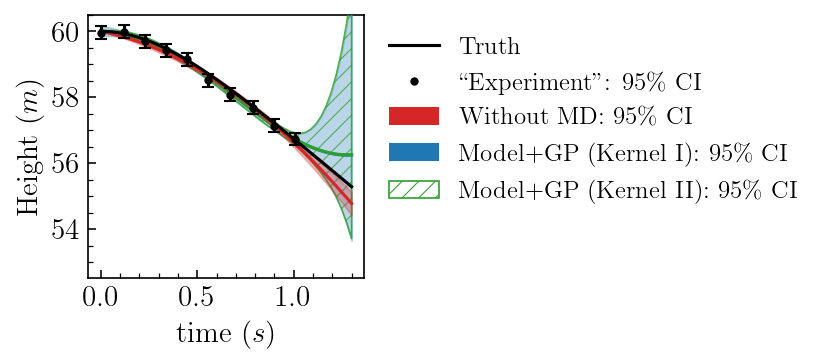

In [12]:
dir_path = "mcmc_data/height"

# load quantiles
num_samples = 20000
mod = 'modelPlusGP'
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_modelPlusGP(exp_data = experimental_data, truth = truth_data, 
               quantiles1 = quantiles_wo_MD, quantiles2 = quantiles_w_MD_kernel1, quantiles3 = quantiles_w_MD_kernel2, 
               true_param = true_param, colors = colors, obs_labels = obs_labels, legends = legends, fig_name=None)


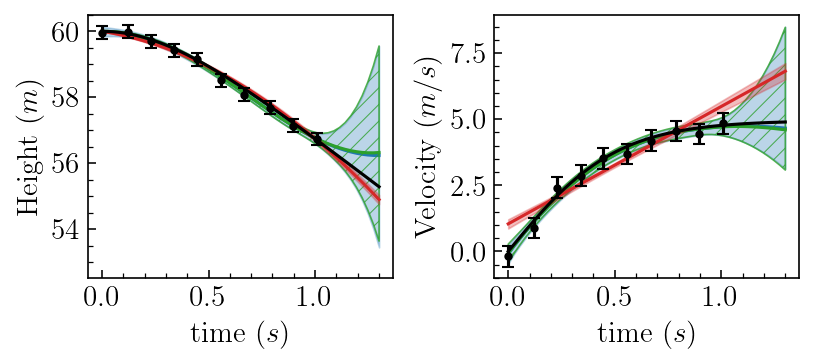

In [13]:
dir_path = "mcmc_data/height_vel"

# load quantiles
num_samples = 20000
mod = 'modelPlusGP'
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_modelPlusGP(exp_data = experimental_data, truth = truth_data, 
               quantiles1 = quantiles_wo_MD, quantiles2 = quantiles_w_MD_kernel1, quantiles3 = quantiles_w_MD_kernel2, 
               true_param = true_param, colors = colors, obs_labels = obs_labels, legends = legends, fig_name=None)

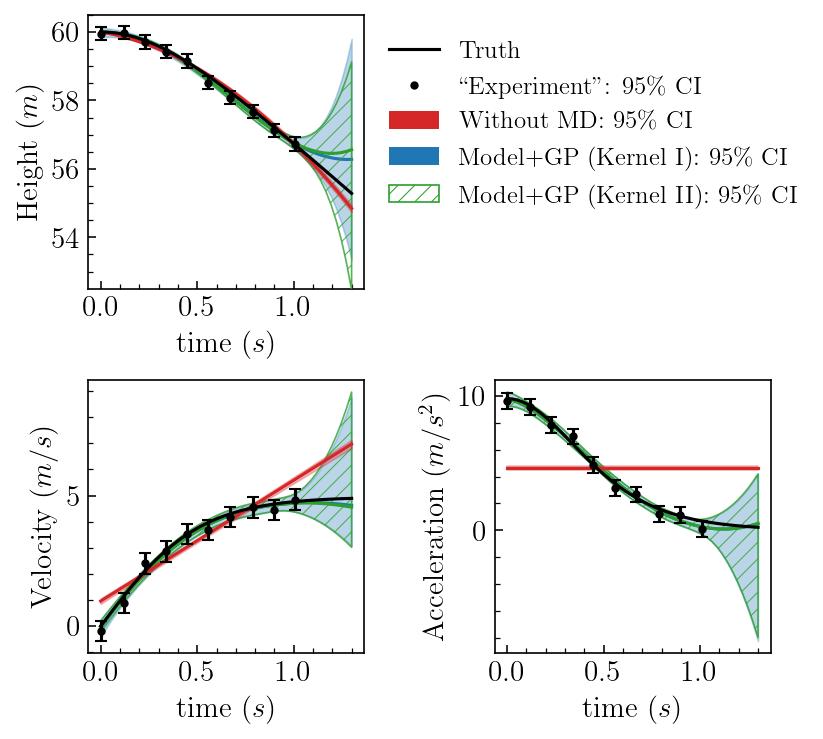

In [14]:
dir_path = "mcmc_data/height_vel_acc"

# load quantiles
num_samples = 20000
mod = 'modelPlusGP'
quantiles_wo_MD = np.loadtxt(f'{dir_path}/wo_MD/quantiles_{num_samples}_model.txt')
quantiles_w_MD_kernel1 = np.loadtxt(f'{dir_path}/w_MD_kernel1/quantiles_{num_samples}_{mod}.txt')
quantiles_w_MD_kernel2 = np.loadtxt(f'{dir_path}/w_MD_kernel2/quantiles_{num_samples}_{mod}.txt')

plot_obs_modelPlusGP(exp_data = experimental_data, truth = truth_data, 
               quantiles1 = quantiles_wo_MD, quantiles2 = quantiles_w_MD_kernel1, quantiles3 = quantiles_w_MD_kernel2, 
               true_param = true_param, colors = colors, obs_labels = obs_labels, legends = legends, fig_name=None)